In [1]:
%pip install -q cmocean
%pip install -q regionmask

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import xarray as xr
import numpy as np
import s3fs
from dask.diagnostics import ProgressBar
import regionmask
import geopandas as gp
from dask import compute
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import pyplot as plt
import cmocean as cm
%matplotlib inline

In [3]:
import functions
#useful for developement to avoid restarting the kernal after updates
#import importlib
#importlib.reload(functions)
from functions import spatial_average,int_variability,ensemble_mean,NH_seaice_regions,SH_seaice_regions,ATL20_area_NH,ATL20_area_SH,MAE,SAE,to_monthly,find_nan_surrounded_by_nan,sel_model

In [4]:
obs_time = slice('2018-11','2024-04')
alt_time = slice('2015','2035')

In [5]:
bucket = 'cmip6-regridded-us-west-2'
experiment = 'SSP245'
grids = ['PolarStereo-N25km','PolarStereo-S25km','EASE2-N25km','EASE2-S25km']
models = ['CESM2','UKESM1-0-LL']
s3 = s3fs.S3FileSystem(anon=True)
fileset_PN,fileset_PS,fileset_EN,fileset_ES = [[s3fs.S3Map(root=f"s3://{bucket}/{experiment}/{grid}/{model}_2015-2035.zarr", s3=s3, check=False) 
                                    for model in models] for grid in grids]

> [!WARNING]  
> `float64` appears needed to avoid RuntimeWarning warnings associated with `float16` and `float32` (e.g., when using `array.sum()`). It may be best to save files as `float64`

In [6]:
#with ProgressBar():
#sea ice variables (except sic) on NSIDC_NH_PolarStereo_25km grid
CMIP6_PN = xr.open_mfdataset(fileset_PN, engine='zarr', consolidated=True).astype('float64')
    
#sea ice variables (except sic) on NSIDC_SH_PolarStereo_25km grid
CMIP6_PS = xr.open_mfdataset(fileset_PS, engine='zarr', consolidated=True).astype('float64')
    
#sea ice concentration on EASE2_N25km grid
CMIP6_EN = xr.open_mfdataset(fileset_EN, engine='zarr', consolidated=True).astype('float64')
    
#sea ice concentration on EASE2_S25km grid
CMIP6_ES = xr.open_mfdataset(fileset_ES, engine='zarr', consolidated=True).astype('float64')

In [7]:
with ProgressBar():
    OSISAF_EN = xr.open_zarr(s3fs.S3Map(root=f's3://{bucket}/obs/EASE2-N25km/OSISAF_2018-11-2024-04.zarr', s3=s3, check=False)).astype('float64').compute()
    OSISAF_ES = xr.open_zarr(s3fs.S3Map(root=f's3://{bucket}/obs/EASE2-S25km/OSISAF_2018-11-2024-04.zarr', s3=s3, check=False)).astype('float64').compute()
    
    IS2_PN = xr.open_zarr(s3fs.S3Map(root=f's3://{bucket}/obs/PolarStereo-N25km/ICESat-2_2018-11-2024-04.zarr', s3=s3, check=False)).astype('float64').compute()
    IS2_PS = xr.open_zarr(s3fs.S3Map(root=f's3://{bucket}/obs/PolarStereo-S25km/ICESat-2_2018-11-2024-04.zarr', s3=s3, check=False)).astype('float64').compute()

[########################################] | 100% Completed | 910.41 ms
[########################################] | 100% Completed | 913.44 ms
[########################################] | 100% Completed | 1.62 sms
[########################################] | 100% Completed | 808.02 ms


In [8]:
OSISAF_EN_CLI = OSISAF_EN.groupby('time.month').mean().assign(sia = lambda x:x.sic.sum(['x', 'y'])*6.25/1e6)
OSISAF_ES_CLI = OSISAF_ES.groupby('time.month').mean().assign(sia = lambda x:x.sic.sum(['x', 'y'])*6.25/1e6)

In [9]:
IS2_PA_mask = regionmask.mask_geopandas(NH_seaice_regions, IS2_PN.lon, IS2_PN.lat,overlap=False)
IS2_PA = IS2_PN.where(IS2_PA_mask.isin([0,1,2,3,4,5,6]))
IS2_PA_grid_cell_weights = IS2_PA.sum(['x','y']).groupby('time.month').count()
IS2_PA_CLI = IS2_PA.groupby('time.month').mean().assign(tfb_annual_grid_fraction = IS2_PA.tfb.groupby('time.month').count()/IS2_PA_grid_cell_weights.tfb,
                                                        sit_annual_grid_fraction = IS2_PA.sit.groupby('time.month').count()/IS2_PA_grid_cell_weights.sit)

IS2_PS_grid_cell_weights = IS2_PS.sum(['x','y']).groupby('time.month').count()
IS2_PS_CLI = IS2_PS.groupby('time.month').mean().assign(tfb_annual_grid_fraction = IS2_PS.tfb.groupby('time.month').count()/IS2_PS_grid_cell_weights.tfb)

In [10]:
CMIP6_PN

<xarray.Dataset> Size: 9GB
Dimensions:        (experiment_id: 1, member_id: 8, time: 252, y: 448, x: 304)
Coordinates:
  * experiment_id  (experiment_id) <U10 40B 'ssp245'
    lat            (y, x) float32 545kB dask.array<chunksize=(448, 304), meta=np.ndarray>
    lon            (y, x) float32 545kB dask.array<chunksize=(448, 304), meta=np.ndarray>
    mask           (y, x) float32 545kB dask.array<chunksize=(448, 304), meta=np.ndarray>
  * member_id      (member_id) <U25 800B 'CESM2_r10i1p1f1' ... 'UKESM1-0-LL_r...
  * time           (time) datetime64[ns] 2kB 2015-01-01 ... 2035-12-01
  * x              (x) float32 1kB -3.838e+06 -3.812e+06 ... 3.712e+06 3.738e+06
  * y              (y) float32 2kB 5.838e+06 5.812e+06 ... -5.312e+06 -5.338e+06
Data variables:
    sit            (experiment_id, member_id, time, y, x) float64 2GB dask.array<chunksize=(1, 1, 252, 448, 304), meta=np.ndarray>
    snt            (experiment_id, member_id, time, y, x) float64 2GB dask.array<chunksize=(1, 1, 252, 448, 304), meta=np.ndarray>
    tfb            (experiment_id, member_id, time, y, x) float64 2GB dask.array<chunksize=(1, 1, 252, 448, 304), meta=np.ndarray>
    tfb_d          (experiment_id, member_id, time, y, x) float64 2GB dask.array<chunksize=(1, 1, 252, 448, 304), meta=np.ndarray>
Attributes:
    SIC_mask:     excludes regions where sea ice concentration is less than 5...
    description:  sea ice variables regridded to NSIDC_NH_PolarStereo_25km grid
    sit:          sea ice thickenss
    snt:          snow thickness
    tfb:          total freeboard (snt + sea ice freeboard)
    tfb_d:        derived total freeboard (snt + derived sea ice freeboard)

In [11]:
ensemble_mean(CMIP6_PN)

<xarray.Dataset> Size: 2GB
Dimensions:        (member_id: 2, experiment_id: 1, time: 252, y: 448, x: 304)
Coordinates:
  * experiment_id  (experiment_id) <U10 40B 'ssp245'
    lat            (y, x) float32 545kB dask.array<chunksize=(448, 304), meta=np.ndarray>
    lon            (y, x) float32 545kB dask.array<chunksize=(448, 304), meta=np.ndarray>
    mask           (y, x) float32 545kB dask.array<chunksize=(448, 304), meta=np.ndarray>
  * time           (time) datetime64[ns] 2kB 2015-01-01 ... 2035-12-01
  * x              (x) float32 1kB -3.838e+06 -3.812e+06 ... 3.712e+06 3.738e+06
  * y              (y) float32 2kB 5.838e+06 5.812e+06 ... -5.312e+06 -5.338e+06
  * member_id      (member_id) <U25 200B 'CESM2' 'UKESM1-0-LL'
Data variables:
    sit            (member_id, experiment_id, time, y, x) float64 549MB dask.array<chunksize=(1, 1, 252, 448, 304), meta=np.ndarray>
    snt            (member_id, experiment_id, time, y, x) float64 549MB dask.array<chunksize=(1, 1, 252, 448, 304), meta=np.ndarray>
    tfb            (member_id, experiment_id, time, y, x) float64 549MB dask.array<chunksize=(1, 1, 252, 448, 304), meta=np.ndarray>
    tfb_d          (member_id, experiment_id, time, y, x) float64 549MB dask.array<chunksize=(1, 1, 252, 448, 304), meta=np.ndarray>
Attributes:
    SIC_mask:     excludes regions where sea ice concentration is less than 5...
    description:  sea ice variables regridded to NSIDC_NH_PolarStereo_25km grid
    sit:          sea ice thickenss
    snt:          snow thickness
    tfb:          total freeboard (snt + sea ice freeboard)
    tfb_d:        derived total freeboard (snt + derived sea ice freeboard)

[########################################] | 100% Completed | 30.98 ss


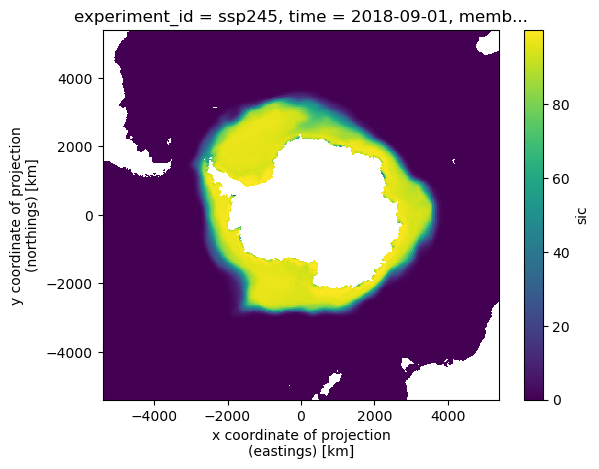

In [12]:
with ProgressBar():
    ensemble_mean(CMIP6_ES).sel(member_id='UKESM1-0-LL',time='2018-09').sic.plot()

[########################################] | 100% Completed | 5.36 sms


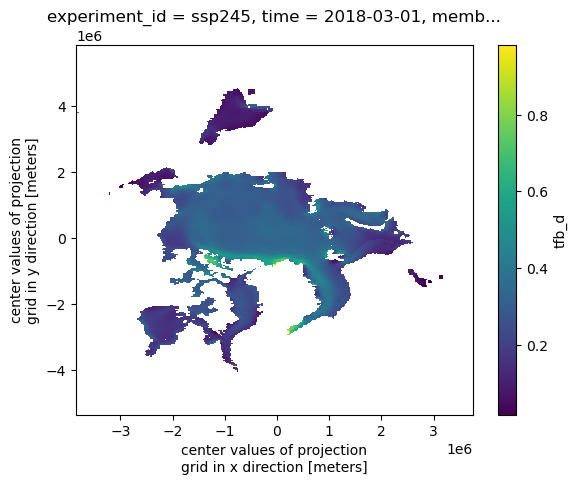

In [13]:
with ProgressBar():
    ensemble_mean(CMIP6_PN).sel(member_id='CESM2',time='2018-03').tfb_d.plot()

Function that applies perennial mask and computes ensemble means, spatial means, internal variability, MAE, and SAE

In [14]:
def error_ds(array, hemisphere, period, rolling=False, window=6):
    if array.name == 'sit':
        obs_data = {'NH': IS2_PA_CLI.sit, 'SH': None}
        obs_annual_grid_fraction = {'NH': IS2_PA_CLI.sit_annual_grid_fraction, 'SH': IS2_PS_CLI.tfb_annual_grid_fraction}
        area_data = {'NH': ATL20_area_NH, 'SH': ATL20_area_SH}
        seasons = {'NH': [[1,2,3,4,9,10,11,12], [12,1,2], [3,4], [9,10,11]],
                   'SH': [[3,4,5,6,7,8,9,10], [6,7,8], [9,10], [3,4,5]]}
        season_index = xr.DataArray([1,2,3,4], coords={"season": np.array(['ANN', 'W', 'SP', 'F'], dtype='U')}, dims=["season"]).season
    elif array.name == 'sic':
        obs_data = {'NH': OSISAF_EN_CLI.sic, 'SH': OSISAF_ES_CLI.sic}
        obs_annual_grid_fraction = {'NH': None, 'SH': None}
        area_data = {'NH': 6.25, 'SH': 6.25}
        seasons = {'NH': [range(1,13,1), [12,1,2], [3,4,5], [6,7,8], [9,10,11]],
                   'SH': [range(1,13,1), [6,7,8], [9,10,11], [12,1,2], [3,4,5]]}
        season_index = xr.DataArray([1,2,3,4,5], coords={"season": np.array(['ANN', 'W', 'SP', 'SU', 'F'], dtype='U')}, dims=["season"]).season
    else:  # Assume TFB case (also works for SNT)
        obs_data = {'NH': IS2_PA_CLI.tfb, 'SH': IS2_PS_CLI.tfb}
        obs_annual_grid_fraction = {'NH': IS2_PA_CLI.tfb_annual_grid_fraction, 'SH': IS2_PS_CLI.tfb_annual_grid_fraction}
        area_data = {'NH': ATL20_area_NH, 'SH': ATL20_area_SH}
        seasons = {'NH': [range(1,13,1), [12,1,2], [3,4,5], [6,7,8], [9,10,11]],
                   'SH': [range(1,13,1), [6,7,8], [9,10,11], [12,1,2], [3,4,5]]}
        season_index = xr.DataArray([1,2,3,4,5], coords={"season": np.array(['ANN', 'W', 'SP', 'SU', 'F'], dtype='U')}, dims=["season"]).season

    # Set common attributes
    obs = obs_data[hemisphere]
    obs_annual_grid_fraction = obs_annual_grid_fraction[hemisphere]
    area = area_data[hemisphere]
    attrs = {'time-period': period.start + ' to ' + period.stop}

    if obs is not None:
        array['lon'], array['lat'] = obs['lon'], obs['lat']
    ocean_mask = array.mask
    
    mae = None
    sae = None
    if array.name == 'sic':
        
        #Compute rolling mean if needed
        dims = ['member_id'] if not rolling else ['member_id', 'year']
        if rolling:
            window = int(window)
            shift = window - 1
            array = to_monthly(array.sel(time=period))\
                    .rolling(year=window, center=False, min_periods=1).mean()\
                    .shift(year=-shift).sel(year=slice(period.start, str(int(period.stop) - shift)))
            attrs['rolling-climatology-window'] = f'{window} years'
        else:
            array = array.sel(time=period).groupby('time.month').mean()
    
        ensemble_mean_data = ensemble_mean(array, thresh=1)
        int_var_data = int_variability(array, thresh=5, dims=dims)
        int_var_seasonal = xr.concat([
            int_variability(array.sel(month=months).mean('month'), thresh=5, dims=dims)
            for months in seasons[hemisphere]
        ], dim=season_index)
        
        spatial_avg = array.sum(['x', 'y'])*area/1e6
        spatial_avg_s = xr.concat([
            array.sel(month=months).mean('month').sum(['x', 'y'])*area/1e6
            for months in seasons[hemisphere]
        ], dim=season_index)
        
        sae = xr.map_blocks(SAE, array,
                            kwargs={'obs': obs, 'weight': 6.25},
                            template=array.isel(x=0, y=0).drop_vars(['x', 'y', 'lat', 'lon', 'mask']))

        sae_s = xr.concat([
            xr.map_blocks(SAE, array.sel(month=months).mean('month'),
                          kwargs={'obs': obs.sel(month=months).mean('month'), 'weight': 6.25},
                          template=array.isel(x=0, y=0,month=0).drop_vars(['x', 'y', 'lat', 'lon', 'mask','month'])) for months in seasons[hemisphere]
        ],dim=season_index)

    elif array.name in ['tfb','tfb_d','sit']:
        
        # Compute rolling mean if needed
        dims = ['member_id'] if not rolling else ['member_id', 'year']
        if rolling:
            window = int(window)
            shift = window - 1
            array = to_monthly(array.fillna(0).sel(time=period))\
                    .rolling(year=window, center=False, min_periods=1).mean()\
                    .shift(year=-shift).sel(year=slice(period.start, str(int(period.stop) - shift)))
            attrs['rolling-climatology-window'] = f'{window} years'
        else:
            array = array.fillna(0).sel(time=period).groupby('time.month').mean()
            
        ###remove zeros from nan streak in UKESM1-0-LL to avoid large values in internal variability
        ###improved version of code that should be included to update how the UKESM1-0-LL is processed in the paper
        if 'UKESM1-0-LL' in ensemble_mean(array).member_id:
            if 'year' in array.dims:
                UKESM1_array = sel_model(array.isel(month=0,year=0),'UKESM1-0-LL').isel(member_id=2)
            else:
                UKESM1_array = sel_model(array.isel(month=0),'UKESM1-0-LL').isel(member_id=2)
            UKESM1_alt_mask = UKESM1_array.mask.where(
                ~find_nan_surrounded_by_nan(UKESM1_array.where(lambda x:x>0),threshold=.6)).fillna(0).squeeze().drop_vars(['month'],errors='ignore')
            array = array.where(lambda x:(x.member_id.str.split('split','_').sel(split=0)!='UKESM1-0-LL') | (x!=0)
                                ,lambda x:x.where(UKESM1_alt_mask),0)
        
        # Apply regional masking
        mask_data = NH_seaice_regions if hemisphere == 'NH' else SH_seaice_regions
        mask = regionmask.mask_geopandas(mask_data, array.lon, array.lat, overlap=False)
        valid_regions = [0, 1, 2, 3, 4, 5, 6] if hemisphere == 'NH' else [0, 1, 2, 3, 4, 5]
        array = array.where(mask.isin(valid_regions)).where(ocean_mask == 1)
        
        ensemble_mean_data = ensemble_mean(array, thresh=1)
        int_var_data = int_variability(array.where(obs_annual_grid_fraction == 1), thresh=5, dims=dims)
        int_var_seasonal = xr.concat([
            int_variability(array.where(obs_annual_grid_fraction == 1).sel(month=months).mean('month'), thresh=5, dims=dims)
            for months in seasons[hemisphere]
        ], dim=season_index)

        spatial_avg = spatial_average(array.where(obs_annual_grid_fraction == 1), area, sector_mean=hemisphere)
        spatial_avg_s = xr.concat([
            spatial_average(array.where(obs_annual_grid_fraction == 1).sel(month=months).mean('month'), area, sector_mean=hemisphere)
            for months in seasons[hemisphere]
        ], dim=season_index)

        if array.name in ['tfb','tfb_d'] or (array.name == 'sit' and hemisphere == 'NH'):
        
            mae = xr.map_blocks(MAE, array.where(obs_annual_grid_fraction == 1),
                                  kwargs={'obs': obs.where(obs_annual_grid_fraction == 1), 'dim': ['x', 'y'], 'weights': area, 'skipna': True},
                                  template=array.isel(x=0, y=0).drop_vars(['x', 'y', 'lat', 'lon', 'mask']))
            
            mae_s = xr.concat([
                xr.map_blocks(MAE, array.where(obs_annual_grid_fraction == 1).sel(month=months).mean('month'),
                              kwargs={'obs': obs.where(obs_annual_grid_fraction == 1).sel(month=months).mean('month'), 'dim': ['x', 'y'], 'weights': area, 'skipna': True},
                              template=array.isel(x=0, y=0, month=0).drop_vars(['x', 'y', 'lat', 'lon', 'mask','month'])) for months in seasons[hemisphere]
            ],dim=season_index)
    
    # Create datasets
    full_ds = xr.Dataset({array.name: array}, attrs=attrs)
    EM_ds = xr.Dataset({array.name: ensemble_mean_data, f'{array.name}_int_var': int_var_data,  f'{array.name}_int_var_seas': int_var_seasonal}, attrs=attrs)
    if array.name == 'sic':
        array.name = 'sia'
    SA_ds_vars = {f'{array.name}': spatial_avg, f'{array.name}_seas': spatial_avg_s}
    if mae is not None:
        SA_ds_vars['MAE'] = mae
        SA_ds_vars['MAE_seas'] = mae_s
    if sae is not None:
        SA_ds_vars['SAE'] = sae
        SA_ds_vars['SAE_seas'] = sae_s
    SA_ds = xr.Dataset(SA_ds_vars, attrs=attrs)
    
    return EM_ds, SA_ds, full_ds

> [!WARNING]  
> Chunk sizes need to be adjusted when saving to avoid PerformanceWarning

In [15]:
CMIP6_PA_TFB_d_EM_CLI, CMIP6_PA_TFB_d_SA_CLI, CMIP6_PA_TFB_d_CLI = error_ds(CMIP6_PN.tfb_d, hemisphere='NH', period=obs_time, rolling=False)
CMIP6_PS_TFB_d_EM_CLI, CMIP6_PS_TFB_d_SA_CLI, CMIP6_PS_TFB_d_CLI = error_ds(CMIP6_PS.tfb_d, hemisphere='SH', period=obs_time, rolling=False)
CMIP6_PA_TFB_d_EM_CLI_r = error_ds(CMIP6_PN.tfb_d, hemisphere='NH', period=alt_time, rolling=True, window=6)[0]
CMIP6_PS_TFB_d_EM_CLI_r = error_ds(CMIP6_PS.tfb_d, hemisphere='SH', period=alt_time, rolling=True, window=6)[0]

/srv/conda/envs/notebook/lib/python3.11/site-packages/xarray/util/deprecation_helpers.py:140: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explicitly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  return func(*args, **kwargs)
/srv/conda/envs/notebook/lib/python3.11/site-packages/xarray/util/deprecation_helpers.py:140: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large c

In [16]:
CMIP6_PA_SIT_EM_CLI, CMIP6_PA_SIT_SA_CLI, CMIP6_PA_SIT_CLI = error_ds(CMIP6_PN.sit, hemisphere='NH', period=obs_time, rolling=False)
CMIP6_PS_SIT_EM_CLI, CMIP6_PS_SIT_SA_CLI, CMIP6_PS_SIT_CLI = error_ds(CMIP6_PS.sit, hemisphere='SH', period=obs_time, rolling=False)
CMIP6_PA_SIT_EM_CLI_r = error_ds(CMIP6_PN.sit, hemisphere='NH', period=alt_time, rolling=False, window=6)[0]
CMIP6_PS_SIT_EM_CLI_r = error_ds(CMIP6_PS.sit, hemisphere='SH', period=alt_time, rolling=False, window=6)[0]

In [17]:
CMIP6_EN_SIC_EM_CLI, CMIP6_EN_SIA_CLI, CMIP6_EN_SIC_CLI = error_ds(CMIP6_EN.sic, hemisphere='NH', period=obs_time, rolling=False)
CMIP6_ES_SIC_EM_CLI, CMIP6_ES_SIA_CLI, CMIP6_ES_SIC_CLI = error_ds(CMIP6_EN.sic, hemisphere='SH', period=obs_time, rolling=False)
CMIP6_EN_SIC_EM_CLI_r = error_ds(CMIP6_EN.sic, hemisphere='NH', period=alt_time, rolling=False, window=6)[0]
CMIP6_ES_SIC_EM_CLI_r = error_ds(CMIP6_EN.sic, hemisphere='SH', period=alt_time, rolling=False, window=6)[0]

In [18]:
with ProgressBar():
    (
        CMIP6_PA_TFB_d_EM_CLI, CMIP6_PA_TFB_d_SA_CLI,
        CMIP6_PS_TFB_d_EM_CLI, CMIP6_PS_TFB_d_SA_CLI,
        CMIP6_PA_TFB_d_EM_CLI_r, CMIP6_PS_TFB_d_EM_CLI_r
    ) = compute(
        CMIP6_PA_TFB_d_EM_CLI, CMIP6_PA_TFB_d_SA_CLI,
        CMIP6_PS_TFB_d_EM_CLI, CMIP6_PS_TFB_d_SA_CLI,
        CMIP6_PA_TFB_d_EM_CLI_r, CMIP6_PS_TFB_d_EM_CLI_r
    )

[########################################] | 100% Completed | 56.08 s


In [19]:
with ProgressBar():
    (
        CMIP6_PA_SIT_EM_CLI, CMIP6_PA_SIT_SA_CLI,
        CMIP6_PS_SIT_EM_CLI, CMIP6_PS_SIT_SA_CLI,
        CMIP6_PA_SIT_EM_CLI_r, CMIP6_PS_SIT_EM_CLI_r
    ) = compute(
        CMIP6_PA_SIT_EM_CLI, CMIP6_PA_SIT_SA_CLI,
        CMIP6_PS_SIT_EM_CLI, CMIP6_PS_SIT_SA_CLI,
        CMIP6_PA_SIT_EM_CLI_r, CMIP6_PS_SIT_EM_CLI_r
    )

[########################################] | 100% Completed | 23.75 s


In [20]:
with ProgressBar():
    (
        CMIP6_EN_SIC_EM_CLI, CMIP6_EN_SIA_CLI,
        CMIP6_ES_SIC_EM_CLI, CMIP6_ES_SIA_CLI,
        CMIP6_EN_SIC_EM_CLI_r, CMIP6_ES_SIC_EM_CLI_r
    ) = compute(
        CMIP6_EN_SIC_EM_CLI, CMIP6_EN_SIA_CLI,
        CMIP6_ES_SIC_EM_CLI, CMIP6_ES_SIA_CLI,
        CMIP6_EN_SIC_EM_CLI_r, CMIP6_ES_SIC_EM_CLI_r
    )

[########################################] | 100% Completed | 29.03 s


In [21]:
def spatial_plot(model,obs,error,int_var=None,obs_unc=0,hem='NH',plot_diff=True,vmin=0,vmax=100,levels=np.arange(0,102,2),months=[1,2,3,4,5,6,7,8,9,10,11,12],plot_type='pcolormesh'):
    fig = plt.figure( figsize=(12,13))
    months = months
    gs = plt.GridSpec(int((np.sqrt(model.member_id.size)+.6).round())
                          ,int((np.sqrt(model.member_id.size)+.6).round()))
    if hem=='NH':
        projection=ccrs.LambertAzimuthalEqualArea(-45, 90)
        extent = [-180, 180, 68, 90]
        if model.name=='sic':
            projection=ccrs.LambertAzimuthalEqualArea(0, 90)
        extent = [-180, 180, 65, 90]
    if hem=='SH':
        projection=ccrs.LambertAzimuthalEqualArea(0, -90)
        extent = [-180, 180, -54, -90]
    if plot_type=='pcolormesh':
        args={'x':'lon','y':'lat','vmin':vmin,'vmax':vmax,'rasterized':True,'transform':ccrs.PlateCarree(),'add_colorbar':False}
    elif plot_type=='contourf':
        args={'x':'x','y':'y','levels':levels,'add_colorbar':False}
    if model.x.units=='km':
        model['x'] = model['x']*1000
        model['y'] = model['y']*1000
    if obs.x.units=='km':
        obs['x'] = obs['x']*1000
        obs['y'] = obs['y']*1000
    if int_var.x.units=='km':
        int_var['x'] = int_var['x']*1000
        int_var['y'] = int_var['y']*1000
    obs_ds = obs.sel(month=months)
    if 'month' in error.coords:
        member_sort = ensemble_mean(error,thresh=1).sel(month=months).mean('month').sortby(lambda x: x).member_id
    else:
        member_sort = error.sortby(lambda x: x).member_id
    model_ds = model.sel(month=months,member_id=member_sort)
    if plot_diff == True:
        if int_var is None:
            axs= [fig.add_subplot(gs[x],projection=projection) for x in range(model.member_id.size)]
            p = [getattr((model_ds.isel(member_id=m)-obs_ds).mean('month').plot, plot_type)(**args,ax=x,cmap=cm.cm.balance_r,extend='both') for x,m in zip(axs,range(model.member_id.size))]
        else:
            axs= [fig.add_subplot(gs[x],projection=projection) for x in range(model.member_id.size+1)]
            p = [getattr((model_ds.isel(member_id=m)-obs_ds).mean('month').plot, plot_type)(**args,ax=x,cmap=cm.cm.balance_r,extend='both') for x,m in zip(axs,range(model.member_id.size))]
            p2 = getattr((int_var).plot,plot_type)(**args,ax=axs[-1],cmap=cm.cm.balance_r,extend='both')
            cs = [(model_ds.isel(member_id=m)-obs_ds).mean('month').where(lambda x:np.abs(x)>int_var+obs_unc).plot.contourf(x='x',y='y',colors='none',hatches=['///'],ax=x,add_colorbar=False) 
                  for x,m in zip(axs,range(model.member_id.size))]
            [cs[m].set_edgecolor('k') for m in range(model.member_id.size)]
            [cs[m].set_linewidths(0) for m in range(model.member_id.size)]
            axs[-1].set_title('Internal Variability')
    if plot_diff == False:
        axs= [fig.add_subplot(gs[x],projection=projection) for x in range(model.member_id.size+1)]
        p = [getattr(model_ds.isel(member_id=m).mean('month').plot,plot_type)(**args,ax=ax,cmap='viridis') 
             for x,m in zip(axs,range(model.member_id.size))]
        getattr(obs_ds.mean('month').plot,plot_type)(**args,ax=axs[-1],cmap='viridis')
        axs[-1].set_title('Observations')

    [x.coastlines(resolution='50m',linewidth=0.15, color = 'black', zorder = 10) for x in axs]
    [x.add_feature(cfeature.LAND, color ='0.95', zorder = 1) for x in axs]
    [x.set_extent(extent, crs=ccrs.PlateCarree()) for x in axs]
    
    [x.set_title('{}'.format(m)) for x,m in zip(axs,member_sort.values)]
    if hem=='NH':
        lon=[50, 50, 50, 50]
        lon2=[-130, -130, -130, -130]
        lat=[90, 90, 90, 40]
        [x.plot(lon, lat, transform=ccrs.PlateCarree(), color='k',ls='--', lw=.75) for x in axs]
        [x.plot(lon2, lat, transform=ccrs.PlateCarree(), color='k',ls='--', lw=.75) for x in axs]
    fig.tight_layout()
    if model.name=='tfb_d':
        if plot_diff==True:
            label='Total Freeboard Differnce [m]'
        if plot_diff==False:
            label='Total Freeboard [m]'
    if model.name=='sit':
        if plot_diff==True:
            label='Sea Ice Thickness Differnce [m]'
        if plot_diff==False:
            label='Sea Ice Thickness [m]'
    if model.name=='sic':
        if plot_diff==True:
            label='Sea Ice Concentration Differnce [%]'
        if plot_diff==False:
            label='Sea Ice Concentration [%]'
    fig.colorbar(p[-1],ax=axs[:], label=label,location='right',pad=0.025,fraction=.025,extend='both')

> [!NOTE]  
>Currently only the UKESM1-0-LL is used for the internal variability in the figures below.

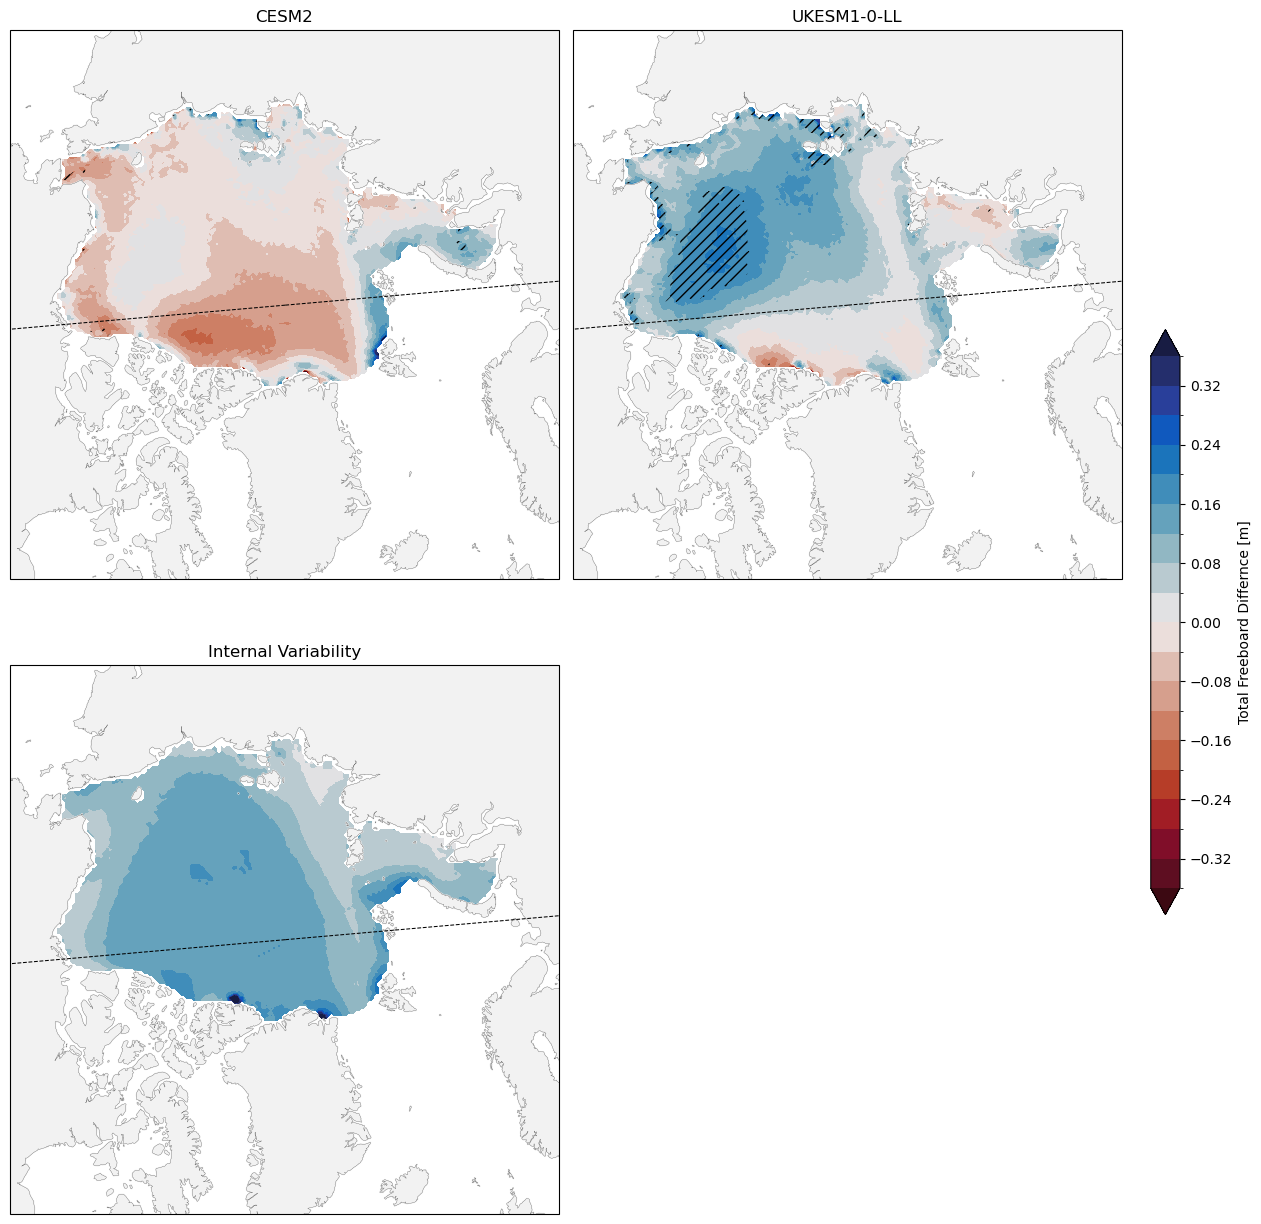

In [22]:
###annual
spatial_plot(model=CMIP6_PA_TFB_d_EM_CLI.tfb_d.where(IS2_PA_CLI.tfb_annual_grid_fraction==1).squeeze(), error=ensemble_mean(CMIP6_PA_TFB_d_SA_CLI.MAE_seas.sel(season='ANN').squeeze())
             , obs=IS2_PA_CLI.tfb.where(IS2_PA_CLI.tfb_annual_grid_fraction==1)
             ,int_var=(np.sqrt(CMIP6_PA_TFB_d_EM_CLI_r.tfb_d_int_var_seas.sel(season='ANN')).mean('member_id')*2).squeeze(),obs_unc=.03
             ,months=[1,2,3,4,5,6,7,8,9,10,11,12], vmin=-.35,vmax=.35,levels=np.arange(-.36,.40,.04),plot_diff=True,hem='NH',plot_type='contourf')

> [!NOTE]  
> In the paper, the "annual" internal variable for sea ice thickness includes the summer months, but it should probably not. In the figures below the internal variability excludes the summer months.

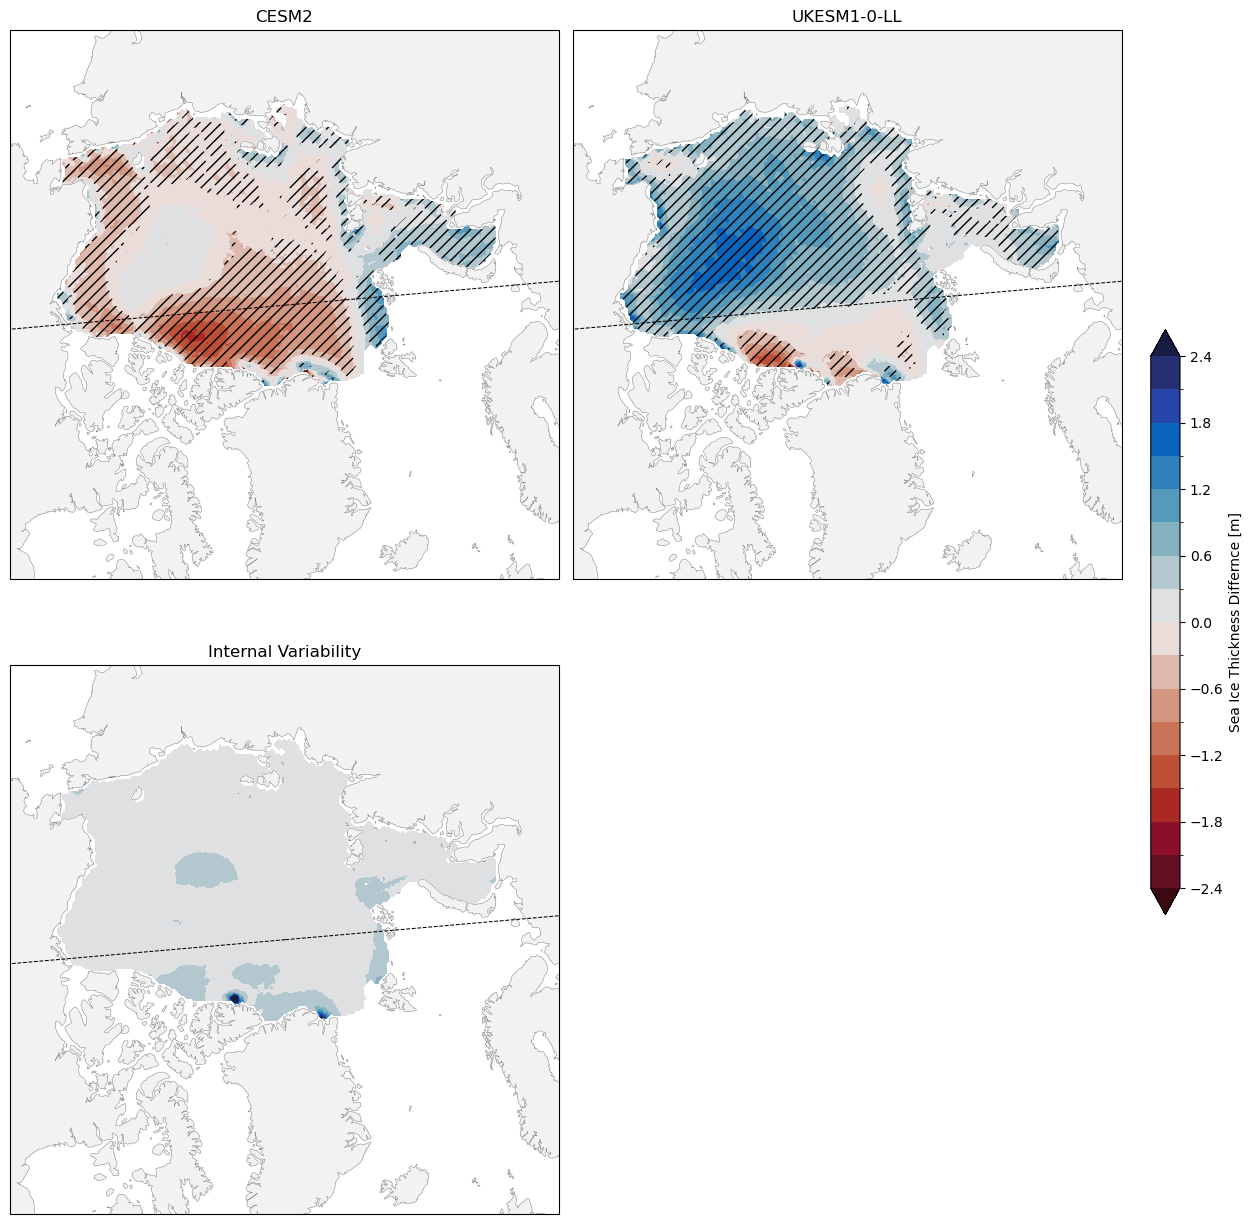

In [23]:
###annual
spatial_plot(model=CMIP6_PA_SIT_EM_CLI.sit.where(IS2_PA_CLI.tfb_annual_grid_fraction==1).squeeze(), error=ensemble_mean(CMIP6_PA_SIT_SA_CLI.MAE_seas.sel(season='ANN').squeeze())
             , obs=IS2_PA_CLI.sit.where(IS2_PA_CLI.sit_annual_grid_fraction==1)
             ,int_var=(np.sqrt(CMIP6_PA_SIT_EM_CLI_r.sit_int_var_seas.sel(season='ANN')).mean('member_id')*2).squeeze(),obs_unc=.03
             ,months=[1,2,3,4,9,10,11,12], vmin=-2.25,vmax=2.25,levels=np.arange(-2.4,2.7,.3),plot_diff=True,hem='NH',plot_type='contourf')

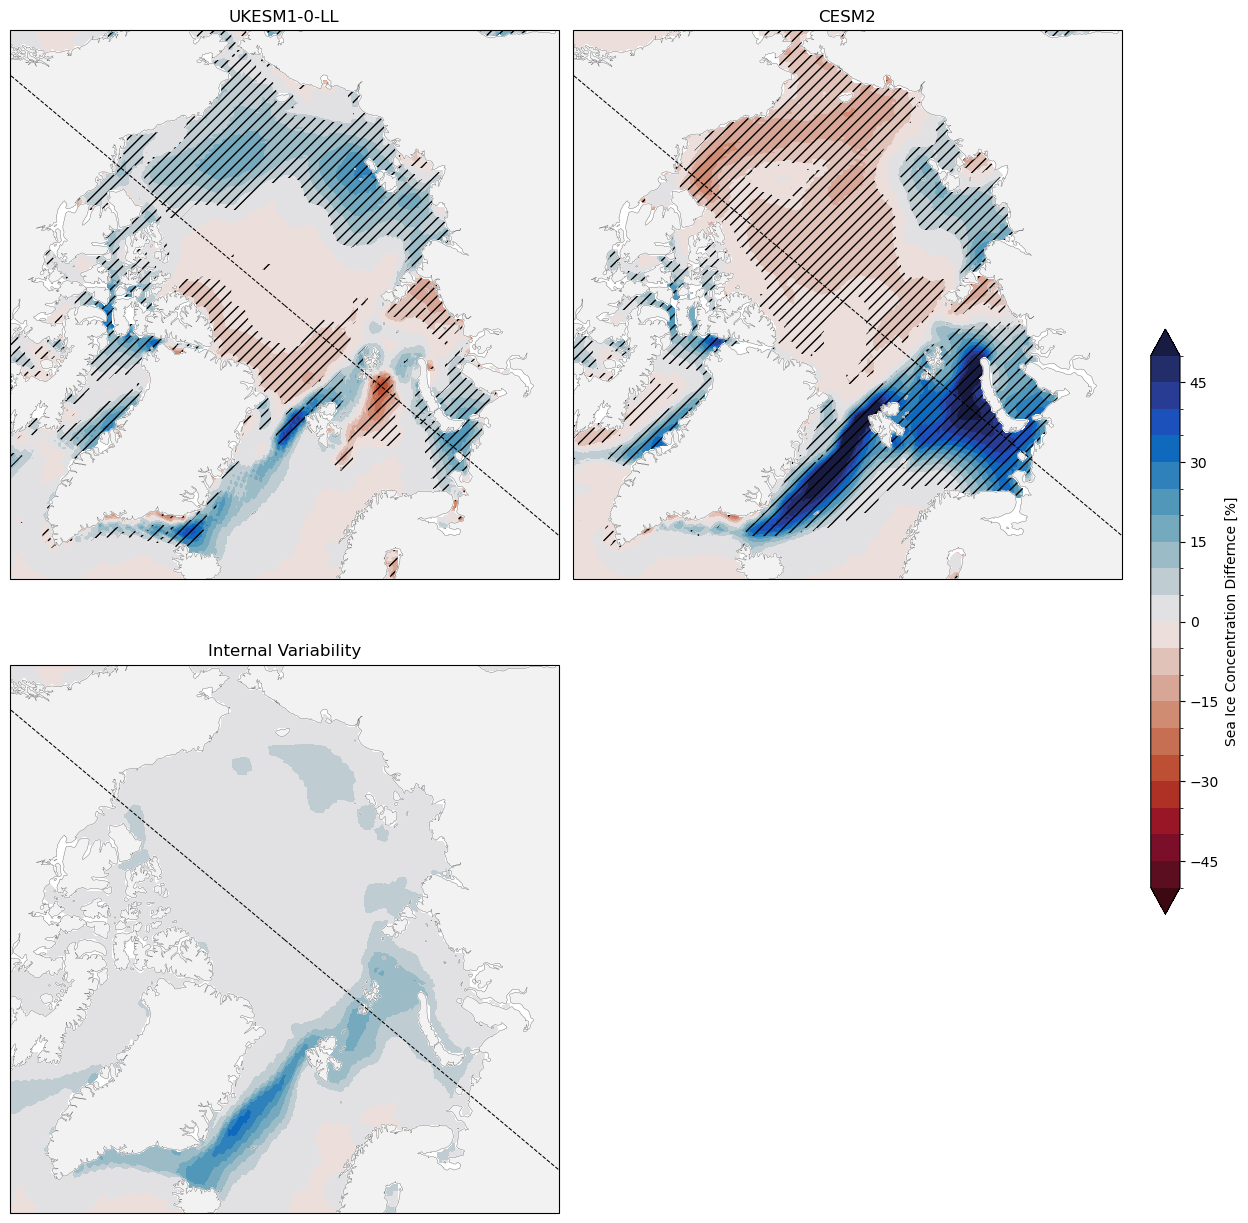

In [24]:
###annual
spatial_plot(model=CMIP6_EN_SIC_EM_CLI.sic.squeeze(), error=ensemble_mean(CMIP6_EN_SIA_CLI.SAE_seas.sel(season='ANN').squeeze())
             , obs=OSISAF_EN_CLI.sic
             ,int_var=(np.sqrt(CMIP6_EN_SIC_EM_CLI_r.sic_int_var_seas.sel(season='ANN')).mean('member_id')*2).squeeze(),obs_unc=.03
             ,months=[1,2,3,4,5,6,7,8,9,10,11,12], vmin=-100,vmax=100,levels=np.arange(-50,55,5),plot_diff=True,hem='NH',plot_type='contourf')